<a href="https://colab.research.google.com/github/Balachandar-Ganesan/GraphRAG/blob/main/TopicModelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.4 MB/s eta 0:00:00


In [19]:
import pandas as pd
from faker import Faker
import random

# Initialize Faker with a locale
fake = Faker('en_US')

def generate_news_dataframe(num_items=100):
    news_list = []

    for _ in range(num_items):
        # 1. Date structured first
        date = fake.date_time_this_year().strftime("%B %d, %Y")

        # 2. Base content generation
        city = fake.city()
        company = fake.company()
        industry = fake.random_element(elements=('Technology', 'Finance', 'Healthcare', 'Energy'))

        headline = f"{company} Announces Major {industry} Breakthrough in {city}"
        summary = " ".join(fake.sentences(nb=random.randint(3, 5)))
        source = fake.company() + " News"

        # 3. Append dictionary to list with Date as the first key
        news_list.append({
            "Date": date,
            "Headline": headline,
            "Summary": summary,
            "Source": source
        })

    # Convert list of dictionaries to a pandas DataFrame
    df = pd.DataFrame(news_list)
    return df

# Generate the 100 news items
news_df = generate_news_dataframe(100)

# Display the first few rows of the DataFrame
print("DataFrame Shape:", news_df.shape)
print("\n--- First 5 Rows Sample ---")
print(news_df.head())


DataFrame Shape: (100, 4)

--- First 5 Rows Sample ---
                Date                                           Headline  \
0  February 27, 2026  Burton Ltd Announces Major Technology Breakthr...   
1     March 09, 2026  Ellis, Romero and Wilson Announces Major Healt...   
2   January 06, 2026  Wise Group Announces Major Healthcare Breakthr...   
3  February 22, 2026  Dyer-Hill Announces Major Finance Breakthrough...   
4       May 01, 2026  Cook LLC Announces Major Energy Breakthrough i...   

                                             Summary  \
0  Television garden campaign plant play. Reveal ...   
1  Bed issue left cultural special recognize hear...   
2  Imagine worry cause own make. Sing enter wonde...   
3  Staff study chair arrive half. Chance full may...   
4  Doctor full or walk knowledge his growth parti...   

                           Source  
0                Spencer PLC News  
1            Oconnor-Watkins News  
2  Reyes, Wilson and Collins News  
3            

In [3]:
!pip install Gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.6 MB/s eta 0:00:00


In [27]:
import re
import argparse
import pandas as pd
import spacy
from spacy.tokens.doc import Doc
from typing import List, Dict, Set, Any
from math import ceil
# Concurrency
from joblib import Parallel, delayed
from functools import partial
from multiprocessing import cpu_count
# gensim
from gensim import corpora
from gensim.models.ldamulticore import LdaMulticore
# plotting
from matplotlib import pyplot as plt
from wordcloud import WordCloud

#inputfile = "../data/nytimes.tsv"
#stopwordfile = "stopwords/custom_stopwords.txt"
# Load spaCy model
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner', 'tagger'])
nlp.add_pipe('sentencizer')


# ============  Methods  =================s
def read_data(filepath: str) -> pd.DataFrame:
    return news_df


def get_stopwords(stopwordfile: str) -> Set[str]:
    stopwords = [
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you",
    "your", "yours", "yourself", "yourselves", "he", "him", "his",
    "himself", "she", "her", "hers"
     ]
    return set(stopwords)


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    "Extract relevant text from DataFrame using a regex"
    print("--- Debugging clean_data (start) ---")
    print(f"Initial DataFrame columns: {df.columns.tolist()}")
    print(f"Sample of DataFrame head:\n{df.head(2).to_markdown(index=False)}")

    # Ensure 'Headline' and 'Summary' are treated as strings and handle potential NaNs
    if 'Headline' not in df.columns or 'Summary' not in df.columns:
        print("Error: 'Headline' or 'Summary' column not found in DataFrame.")
        raise KeyError("Required columns 'Headline' or 'Summary' missing.")

    df['Headline'] = df['Headline'].astype(str).fillna('')
    df['Summary'] = df['Summary'].astype(str).fillna('')
    print(f"Columns after type conversion: {df.columns.tolist()}")

    # Combine 'Headline' and 'Summary' into a new 'content' column
    df['content'] = df['Headline'] + ' ' + df['Summary']
    print(f"Columns after creating 'content': {df.columns.tolist()}")
    print(f"Sample of 'content' column:\n{df['content'].head(2).to_markdown(index=False)}")

    # Regex pattern for only alphanumeric, hyphenated text with 3 or more chars
    pattern = re.compile(r"[A-Za-z0-9\-]{3,50}")
    df['clean'] = df['content'].str.findall(pattern).str.join(' ')
    df['clean'] = df['clean'].str.lower()  # Lowercase text before lemmatization
    print("--- Debugging clean_data (end) ---")
    return df


def lemmatize(doc: Doc, stopwords: Set[str]) -> List[str]:
    "Perform lemmatization and stopword removal in the clean text"
    lemma_list = [tok.lemma_ for tok in doc
                  if tok.is_alpha and tok.text not in stopwords]
    return lemma_list


def chunker(iterable: List[str], total_length: int, chunksize: int):
    return (iterable[pos: pos + chunksize] for pos in range(0, total_length, chunksize))


def flatten(list_of_lists: List[List[str]]) -> List[str]:
    "Flatten a list of lists to a combined list"
    return [item for sublist in list_of_lists for item in sublist]


def process_chunk(stopwords: Set[str], texts: List[str]) -> List[List[str]]:
    preproc_pipe = []
    for doc in nlp.pipe(texts, batch_size=20):
        preproc_pipe.append(lemmatize(doc, stopwords))
    return preproc_pipe


def preprocess_concurrent(texts: List[str], stopwords: Set[str], chunksize: int=100):
    executor = Parallel(n_jobs=params['n_proc'], backend='multiprocessing', prefer="processes")
    do = delayed(partial(process_chunk, stopwords))
    tasks = (do(chunk) for chunk in chunker(texts, len(texts), chunksize=chunksize))
    result = executor(tasks)
    return flatten(result)


def run_lda_multicore(
        text_df: pd.DataFrame,
        params: Dict[str, Any],
        workers: int = 7
    ):
    """Run Gensim's multicore LDA topic modelling algorithm
       Choose number of workers for multicore LDA as (num_physical_cores - 1)
    """
    print("Applying LDA algorithm...")
    id2word = corpora.Dictionary(text_df['lemmas'])
    # Filter out words that occur in less than 2% documents or more than 50% of the documents.
    id2word.filter_extremes(no_below=params['minDF'], no_above=params['maxDF'])
    corpus = [id2word.doc2bow(text) for text in text_df['lemmas']]
    # LDA Model
    lda_model = LdaMulticore(
        corpus=corpus,
        id2word=id2word,
        workers=workers,
        num_topics=params['topics'],
        random_state=1,
        chunksize=2048,
        passes=params['epochs'],
        iterations=params['iter'],
    )
    return lda_model, corpus


def plot_wordclouds(topics: List[Dict[str, float]],
                    colormap: str="cividis") -> None:
    cloud = WordCloud(
        background_color='white',
        width=600,
        height=400,
        colormap=colormap,
        prefer_horizontal=1.0,
    )

    num_topics = len(topics)
    # Hacky way to scale figure size based on the number of topics specified
    fig_width = min(ceil(0.6 * num_topics + 6), 20)
    fig_height = min(ceil(0.65 * num_topics), 20)
    fig = plt.figure(figsize=(fig_width, fig_height))

    for idx, word_weights in enumerate(topics):
        ax = fig.add_subplot(ceil(num_topics / 5), 5, idx + 1)
        wordcloud = cloud.generate_from_frequencies(word_weights)
        ax.imshow(wordcloud, interpolation="bilinear")
        ax.set_title('Topic {}'.format(idx + 1))
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.tick_params(length=0)

    plt.tick_params(labelsize=14)
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    plt.margins(x=0.1, y=0.1)
    st = fig.suptitle("LDA Topics", y=0.92)
    fig.savefig(
        f"gensim_topics_k={params['topics']}.png",
        bbox_extra_artists=[st], bbox_inches='tight'
    )


def main(params: Dict[str, Any]) -> None:
    df = read_data("")
    stopwords = get_stopwords("")
    print(f'Beginning text preprocessing...')
    df_preproc = clean_data(df)
    df_preproc['lemmas'] = preprocess_concurrent(df_preproc['clean'], stopwords)
    print('Finished preprocessing {} samples'.format(df_preproc.shape[0]))
    model, corpus = run_lda_multicore(df_preproc, params, workers=params['n_proc'])
    topic_list = model.show_topics(formatted=False,
                                   num_topics=params['topics'],
                                   num_words=20)
    # Store topic words amd weights as a list of dicts
    topics = [dict(item[1]) for item in topic_list]

    print(f"\n--- Displaying {params['topics']} LDA Topics (Top 20 words each) ---")
    for i, topic_item in enumerate(topic_list):
        # topic_item is a tuple: (topic_id, [(word, probability), ...])
        print(f"Topic {i+1}:")
        # Sort words by probability in descending order and take top 20
        sorted_words = sorted(topic_item[1], key=lambda x: x[1], reverse=True)[:20]
        for word, prob in sorted_words:
            print(f"  - {word} (probability: {prob:.4f})")
        print("-" * 30) # Separator for readability

    plot_wordclouds(topics)

{'topics': 20, 'iter': 150, 'epochs': 10, 'minDF': 0.02, 'maxDF': 0.8, 'n_proc': 3}
Beginning text preprocessing...
--- Debugging clean_data (start) ---
Initial DataFrame columns: ['Date', 'Headline', 'Summary', 'Source', 'content', 'clean', 'lemmas']
Sample of DataFrame head:
| Date              | Headline                                                                           | Summary                                                                                                                                                                          | Source               | content                                                                                                                                                                                                                                         | clean                                                                                                                                                                      

/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:187: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


Finished preprocessing 100 samples
Applying LDA algorithm...

--- Displaying 20 LDA Topics (Top 20 words each) ---
Topic 1:
  - heavy (probability: 0.0117)
  - standard (probability: 0.0117)
  - million (probability: 0.0117)
  - technology (probability: 0.0117)
  - gas (probability: 0.0117)
  - newspaper (probability: 0.0117)
  - street (probability: 0.0117)
  - process (probability: 0.0117)
  - healthcare (probability: 0.0117)
  - and (probability: 0.0117)
  - itself (probability: 0.0117)
  - item (probability: 0.0117)
  - issue (probability: 0.0117)
  - new (probability: 0.0117)
  - estes (probability: 0.0060)
  - product (probability: 0.0060)
  - bill (probability: 0.0060)
  - gilbert (probability: 0.0060)
  - get (probability: 0.0060)
  - someone (probability: 0.0060)
------------------------------
Topic 2:
  - healthcare (probability: 0.0168)
  - and (probability: 0.0168)
  - new (probability: 0.0126)
  - owner (probability: 0.0126)
  - but (probability: 0.0085)
  - worker (probab

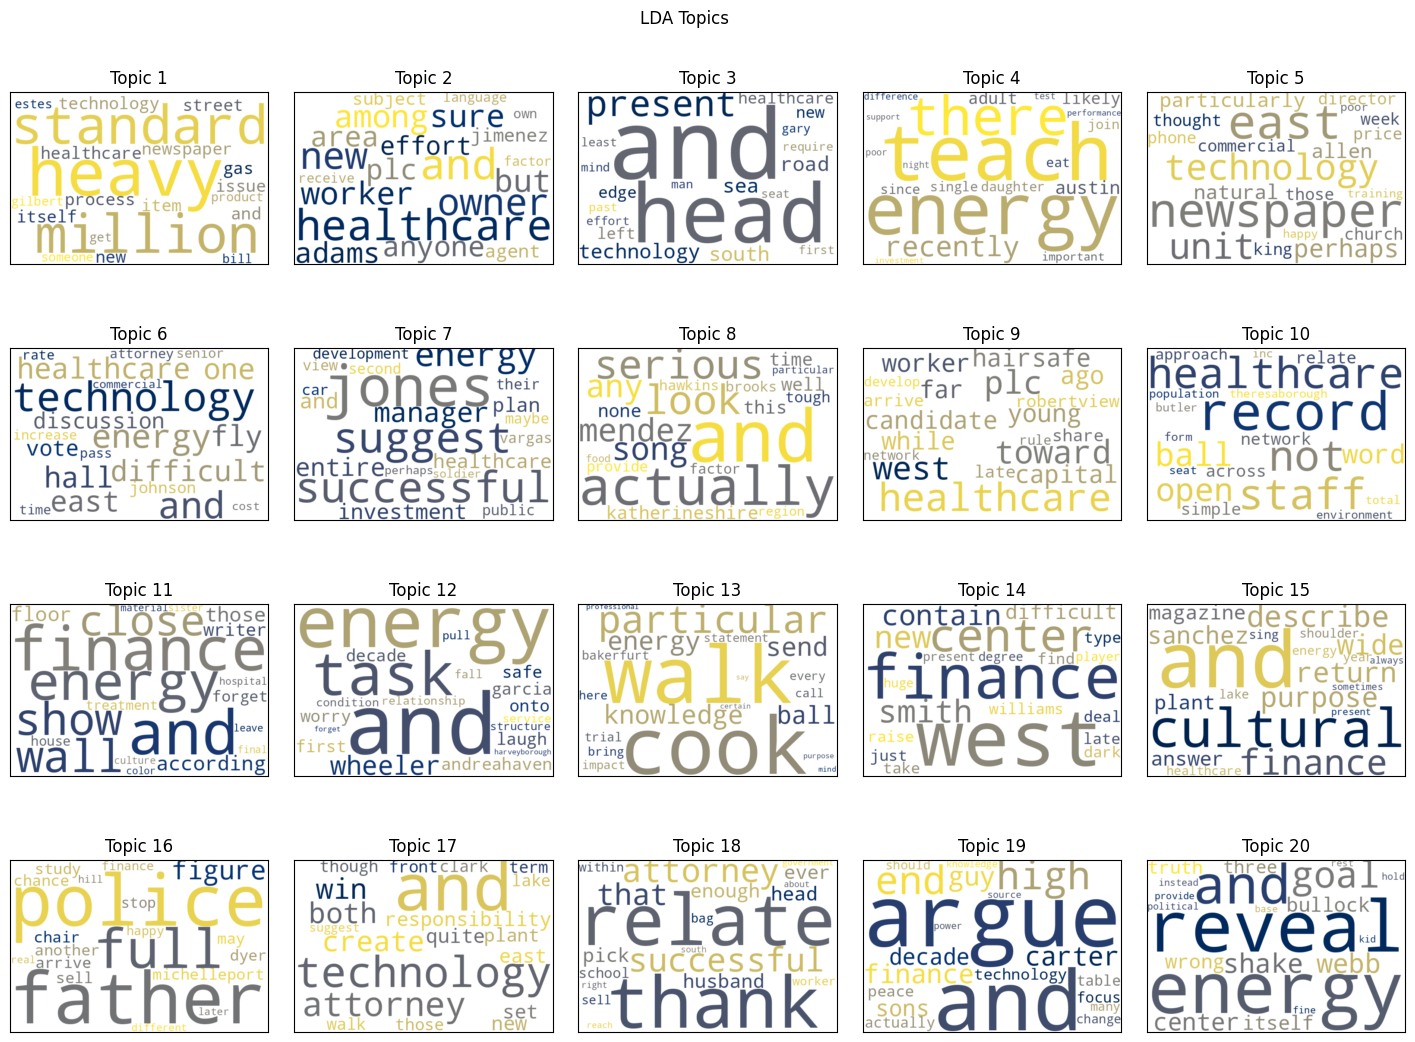

In [28]:
    parser = argparse.ArgumentParser()
    parser.add_argument("--topics", "-t", type=int, default=20, help="Number of topics in LDA")
    parser.add_argument("--iter", "-i", type=int, default=150, help="Max iterations in LDA")
    parser.add_argument("--epochs", "-e", type=int, default=10, help="Max number of epochs for Gensim")
    parser.add_argument("--minDF", "-m1", type=float, default=0.02, help="Minimum document frequency")
    parser.add_argument("--maxDF", "-m2", type=float, default=0.8, help="Maximum document frequency")
    parser.add_argument("--n_proc", "-n", type=int, default=cpu_count() + 1, help="Number of CPU processes")

    params = vars(parser.parse_args([]))
    # Run LDA
    print(params)
    main(params)